In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [10]:
# width = 1200
# height = 1800
# cutout_left = 900
# cutout_top = 800
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

In [11]:
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
# Remember that the edges are all defined in world coordinates.

margin = 100

wx_range = np.arange(-margin, width + margin)
wy_range = np.arange(-margin, height + margin)
wx_map, wy_map = np.meshgrid(wx_range, wy_range, indexing='ij')
low_probability = 10 ** -10

In [14]:
def plot_map(map_data, axs=None, title=None):
    if axs is None:
        plt.figure(figsize=(8, 8))
        axs = plt.gca()
    if title is not None:
        axs.set_title(title)
    axs.imshow(
        map_data.T,
        cmap='gray',
        origin='lower',
        extent=[wx_range[0], wx_range[-1], wy_range[0], wy_range[-1]]
    )

In [13]:
corners = np.array([
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
])

edges = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
])

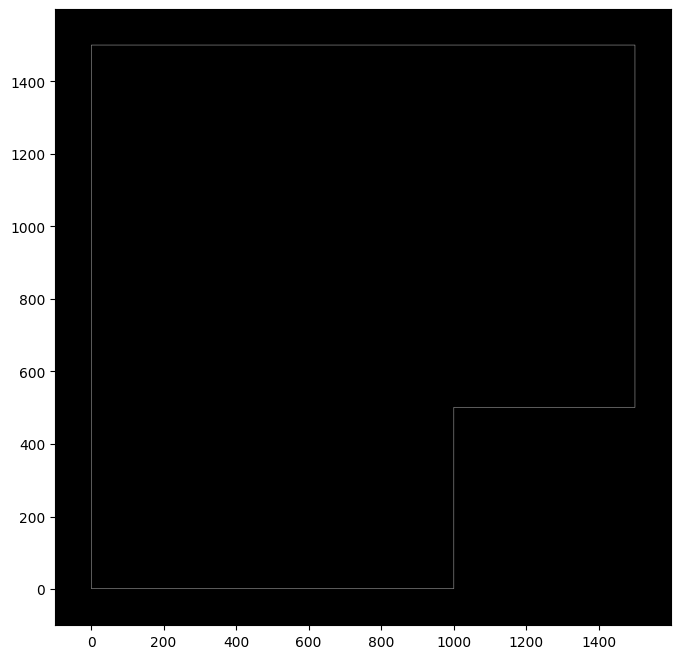

In [15]:
# Create the probability map with edges drawn as 1.0
distance_field = np.full_like(wx_map, low_probability, dtype=np.float32)
for edge in edges:
    p1 = corners[edge[0]] + (margin, margin)
    p2 = corners[edge[1]] + (margin, margin)
    cv2.line(distance_field, p1[::-1], p2[::-1], color=1.0, thickness=1)
# distance_field = distance_field
plot_map(distance_field)

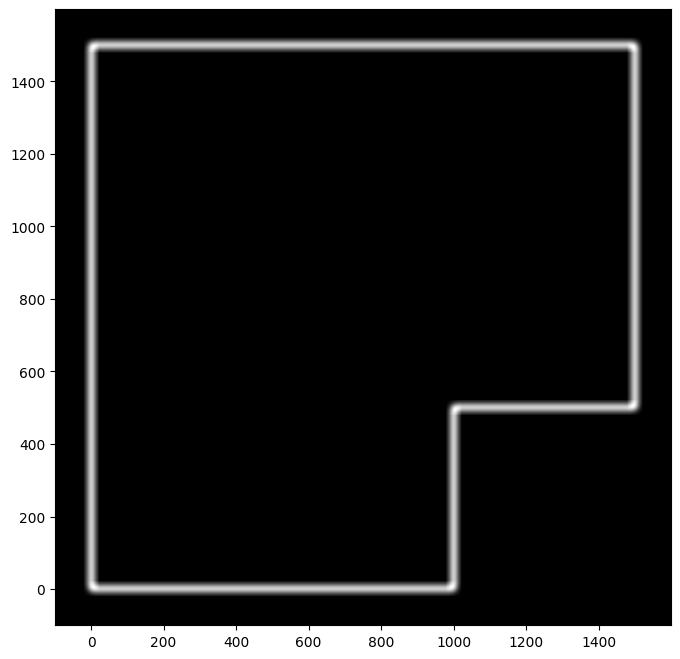

In [16]:
# Blur this map
distance_span = 41
blurred_distance = cv2.GaussianBlur(distance_field, (distance_span, distance_span), 10)
plot_map(blurred_distance)

In [17]:
blurred_distance[100, 100]

np.float32(0.04156866)

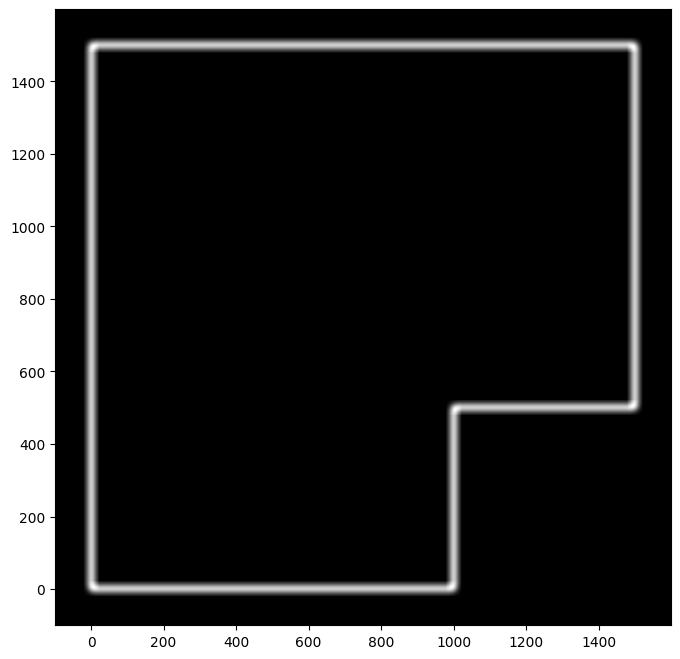

In [18]:
# Scale so every pixel is between 0 and 1
blurred_distance -= blurred_distance.min()
blurred_distance /= blurred_distance.max()
blurred_distance += low_probability
plot_map(blurred_distance)

In [19]:
np.max(blurred_distance)

np.float32(1.0)

In [20]:
population_size = 20000
rng = np.random.default_rng()
poses = np.column_stack((
            rng.uniform(0, width, population_size),
            rng.uniform(0, height, population_size),
            rng.uniform(0, 2 * np.pi, population_size)
        ))

In [21]:
polar_middle_to_sensor = (50, 0) # distance (r), angle (theta)
fov_w = np.pi / 4

In [22]:
w_segments = np.linspace(-fov_w/2, fov_w/2, 8)
latest_readings = np.zeros_like(w_segments, dtype=object)
w_segments

array([-0.39269908, -0.28049934, -0.16829961, -0.05609987,  0.05609987,
        0.16829961,  0.28049934,  0.39269908])

In [23]:
# Make some fake inputs - row of 8 distance readings
input_readings = [150, 151, 152, 153, 154, 155, 156, 157]
input_readings

[150, 151, 152, 153, 154, 155, 156, 157]

In [24]:
# Create the set of polar vectors from the robot center to each reading
sensor_polar_vectors = np.array(list(zip(input_readings, w_segments))) + polar_middle_to_sensor
sensor_polar_vectors

array([[ 2.00000000e+02, -3.92699082e-01],
       [ 2.01000000e+02, -2.80499344e-01],
       [ 2.02000000e+02, -1.68299606e-01],
       [ 2.03000000e+02, -5.60998688e-02],
       [ 2.04000000e+02,  5.60998688e-02],
       [ 2.05000000e+02,  1.68299606e-01],
       [ 2.06000000e+02,  2.80499344e-01],
       [ 2.07000000e+02,  3.92699082e-01]])

In [83]:
def get_sensor_endpoints(poses, sensor_polar_vector, margin) -> np.ndarray:
    """Given an array of poses (x, y, theta) and a sensor polar vector (r, theta),
    return the world coordinates of the sensor endpoints."""
    sensor_angles = poses[:, 2] + sensor_polar_vector[1]
    sensor_endpoints = np.zeros((poses.shape[0], 2), dtype=np.float32)
    sensor_endpoints[:,0] = poses[:, 0] + sensor_polar_vector[0] * np.cos(sensor_angles) + margin
    # now clip
    np.clip(sensor_endpoints[:,0], 0, distance_field.shape[0]-1, out=sensor_endpoints[:,0])
    sensor_endpoints[:,1] = poses[:, 1] + sensor_polar_vector[0] * np.sin(sensor_angles) + margin
    np.clip(sensor_endpoints[:,1], 0, distance_field.shape[1]-1, out=sensor_endpoints[:,1])
    return sensor_endpoints.astype(int)

In [81]:
def observe_distance_sensors(poses, sensor_polar_vectors, distance_field, margin) -> np.ndarray:
    summed_weights = np.zeros((poses.shape[0]), dtype=np.float32)

    for sensor_polar_vector in sensor_polar_vectors:
        sensor_endpoints = get_sensor_endpoints(poses, sensor_polar_vector, margin)
        weights = distance_field[sensor_endpoints[:,0], sensor_endpoints[:,1]]
        summed_weights += weights
    # Weight should be an array of shape (num_poses,) with the summed weights
    return summed_weights

In [89]:
weights = np.zeros((poses.shape[0]), dtype=np.float32)
sensor_endpoints = get_sensor_endpoints(poses, sensor_polar_vectors[0], margin)
# sensor_endpoints[0], np.shape(distance_field[sensor_endpoints[:,0], sensor_endpoints[:,1]]), np.shape(poses)[0]
weights = distance_field[sensor_endpoints[:,0], sensor_endpoints[:,1]]
np.shape(weights), weights[1]

# Take is 1d - flattened... Ok.

((20000,), np.float32(1e-10))

Let's generate the weights for the sensors using these functions

In [84]:
weights = observe_distance_sensors(poses, sensor_polar_vectors, blurred_distance, margin)

In [86]:
np.shape(weights)

(20000,)

Let's plot this

(8, 400, 3)
1.0 1e-10


<Figure size 800x800 with 0 Axes>

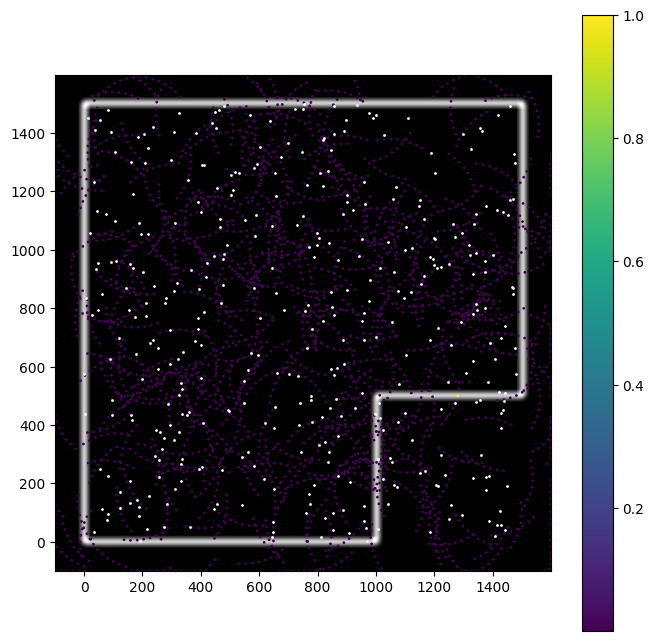

In [137]:
from cgitb import small
from matplotlib.pyplot import sca


plt.figure(figsize=(8, 8))
plot_map(blurred_distance)

scatter_points = np.zeros(
    [np.shape(sensor_polar_vectors)[0], np.shape(poses)[0],  3], 
    dtype=np.float32) # (x, y, weight)
for n, sensor_polar_vector in enumerate(sensor_polar_vectors):
    sensor_endpoints = get_sensor_endpoints(poses, sensor_polar_vector, margin)
    weights = distance_field[sensor_endpoints[:,0], sensor_endpoints[:,1]]
    world_endpoints = sensor_endpoints - [margin, margin]
        # Extend scatter points with world_endpoints x,y and weights
    scatter_points[n, :, :] =np.column_stack(
        [world_endpoints[:,0], world_endpoints[:,1], weights]
    )
sample_set = slice(0, 400)

# For the given sample set, stack all the scatter points
sampled_points = scatter_points[:, sample_set, :]
print(np.shape(sampled_points))
print(np.max(sampled_points[:, :, 2]), np.min(sampled_points[:, :, 2]))
detections = plt.scatter(
    sampled_points[:, :, 0], sampled_points[:, :, 1], 
    s=1, c=sampled_points[:, :, 2], cmap='viridis'
)
plt.colorbar(detections)

plt.scatter(poses[sample_set,0], poses[sample_set,1], s=1, c='white')